# Context-Aware Digital Phenotyping
## Passive Signals, Active Confounds
**Team:** Aruzhan Oshakbayeva, Azhar Serik, Libby Thogmartin

**Research Question:** If we combine passive smartphone data with contextual confound data, does the relationship between phone signals and self-reported mood change?

**Dataset:** StudentLife (Wang et al., 2014) - 49 Dartmouth students, Spring 2013 term, 10 weeks of continuous passive sensing.

The notebooks consists of 4 parts: 
 - 1. Imports and Setup
 - 2. Data collecting, processing and merging
 - 3. Feature Engineering 
 - 4. Three-model comparison

**Data collection methods used in this project include:**
 - **1. Fetching Open Meteo Weather API for weather data**
 - **2. Scraping GDELT news event data via HTTP (requests)**
 - **3. Fetching  Google Trends search data via pytrends API**

##  1. Imports and Setup
All required libraries, file paths, study parameters, and participant UIDs.

UIDs in this dataset are not sequential - several numbers are skipped. The correct list of 49 UIDs was derived by listing the actual files in the sensing/activity folder.

All participant UIDs are irreversibly hashed using SHA-256 before any data is stored, satisfying GDPR Art. 25 (privacy by design).

In [68]:
import os
import io
import json
import time
import hashlib
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pathlib import Path
from math import radians, sin, cos, sqrt, atan2
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings

# ─────────────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────────────

DATA_DIR      = Path("data/studentlife")
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────
# STUDY PARAMETERS
# ─────────────────────────────────────────────────────────────────

# Official Dartmouth Spring 2013 term dates
# Source: Dartmouth Office of the Registrar Spring 2013 Term Calendar
STUDY_START = pd.Timestamp("2013-03-25", tz="US/Eastern")
STUDY_END   = pd.Timestamp("2013-06-03", tz="US/Eastern")

# Actual participant UIDs present in the dataset
# NOTE: IDs are NOT sequential 0-48. Several numbers are skipped
# (u06, u11, u21, u26, u28, u29, u37, u38, u40, u48, u55 do not exist)
# These were derived by listing the actual files in the sensing/activity folder
UIDS = [
    "u00","u01","u02","u03","u04","u05","u07","u08","u09","u10",
    "u12","u13","u14","u15","u16","u17","u18","u19","u20","u22",
    "u23","u24","u25","u27","u30","u31","u32","u33","u34","u35",
    "u36","u39","u41","u42","u43","u44","u45","u46","u47","u49",
    "u50","u51","u52","u53","u54","u56","u57","u58","u59"
]

# ─────────────────────────────────────────────────────────────────
# PRIVACY: UID HASHING
# ─────────────────────────────────────────────────────────────────

# All participant UIDs are irreversibly hashed before any data is stored.
# We use SHA-256 with a salt string. The raw UID is never passed downstream.
# This satisfies GDPR Art. 25 (privacy by design / data minimisation).

def hash_uid(uid, salt="ddcm_2024"):
    return hashlib.sha256(f"{salt}:{uid}".encode()).hexdigest()[:16]

uid_map = {uid: hash_uid(uid) for uid in UIDS}

# ─────────────────────────────────────────────────────────────────
# GPS HELPER — HAVERSINE DISTANCE
# ─────────────────────────────────────────────────────────────────

# Computes straight-line distance between two lat/lon points in km.
# Used to convert raw GPS coordinates to distance from Dartmouth campus.

DARTMOUTH_LAT = 43.7044
DARTMOUTH_LON = -72.2887

def haversine_km(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance in km between two coordinates."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

print(f"Participants: {len(UIDS)}")
print(f"Study period: {STUDY_START.date()} to {STUDY_END.date()}")
print(f"Example hash: u00 -> {uid_map['u00']}")

Participants: 49
Study period: 2013-03-25 to 2013-06-03
Example hash: u00 -> cd6251b4de52453b


## 2.Data Loading, Preprocessing and Merging
Raw data is loaded from the StudentLife dataset and saved to `data/processed/` as clean CSVs.

**2.1 Outcome variable:**
- PAM (Photographic Affect Meter) - daily mean affect score, validated against PANAS Positive Affect at r=0.71 (Pollak et al., 2011)

** Passive smartphone signals:**
- **2.2 Activity** - fraction of day spent stationary (accelerometer)
- **2.3 Dark periods** - total screen-off hours per day (sleep proxy)
- **2.4 Conversation** - total detected voice hours per day (social activity proxy, no audio content recorded)
- **2.5 GPS** - daily distance from Dartmouth campus (mobility proxy, raw coordinates immediately discarded)

**2.6 Contextual confound:**
- **Deadlines** - per-participant, per-day deadline count from education records

** External contextual confounds (collected in this section):**
- **2.7 Weather** - daily weather conditions via Open-Meteo Historical API
- **2.8 Societal events** - GDELT 1.0 news event database + Google Trends anxiety signal
- **2.9 Academic calendar** - Dartmouth Office of the Registrar, Spring 2013
- **2.10 Holidays**

All processed CSVs are loaded and merged into a single master dataframe at the participant-day level.

Steps:
1. Standardise all date columns to tz-naive
2. Outer merge all files on hashed_uid + date
3. Drop rows where PAM score is missing
4. Add weekday/weekend flag
5. Add weather category derived from weather code
6. Add US holiday flags for Spring 2013
7. Merge GDELT compound mood signal
8. Verify final shape and missing rates

## 2.1 PAM

In [69]:
# ─────────────────────────────────────────────────────────────────
# PAM (PHOTOGRAPHIC AFFECT METER) — PRIMARY MOOD OUTCOME
# ─────────────────────────────────────────────────────────────────

# PAM is a validated in-situ measure of affect where students select
# one of 16 photos arranged in a 4x4 grid representing Russell's
# two-dimensional affect space (valence x arousal).
# It was fired before every other EMA prompt in StudentLife, guaranteeing
# high compliance: 6,660 entries across 49 participants vs 137 for Mood EMA.
#
# Validation: PAM correlates with PANAS Positive Affect at r=0.71 (p<0.001)
# Source: Pollak, Adams & Gay (2011). PAM: A Photographic Affect Meter
#         for Frequent, In Situ Measurement of Affect. CHI 2011.
#
# Scoring: The raw picture_idx (1-16) is used as the analytical variable.
# Higher scores = higher positive affect. For presentation purposes only,
# scores map to four quadrants from Figure 3 of Pollak et al. (2011):
#   1-4  = Negative valence / Low arousal  (sad, depressed, bored)
#   5-8  = Negative valence / High arousal (stressed, anxious, angry)
#   9-12 = Positive valence / Low arousal  (calm, content, relaxed)
#   13-16= Positive valence / High arousal (excited, happy, enthusiastic)
#
# We take the daily MEAN PAM score per participant since PAM fires
# multiple times per day (once before each EMA prompt).

pam_records = []

for uid in UIDS:
    fpath = DATA_DIR / "EMA" / "response" / "PAM" / f"PAM_{uid}.json"
    if not fpath.exists():
        continue

    with open(fpath) as f:
        entries = json.load(f)

    for entry in entries:
        try:
            picture_idx = entry.get("picture_idx")
            resp_time   = entry.get("resp_time")
            if picture_idx is None or resp_time is None:
                continue
            pam_records.append({
                "hashed_uid": uid_map[uid],
                "resp_time":  resp_time,
                "pam_score":  int(picture_idx)
            })
        except (TypeError, ValueError):
            continue

df_pam = pd.DataFrame(pam_records)
df_pam["datetime"] = pd.to_datetime(df_pam["resp_time"], unit="s", utc=True).dt.tz_convert("US/Eastern")
df_pam["date"]     = df_pam["datetime"].dt.normalize()

# Filter to study period
df_pam = df_pam[
    (df_pam["date"] >= STUDY_START.normalize()) &
    (df_pam["date"] <= STUDY_END.normalize())
]

# Aggregate to daily mean
df_pam = (df_pam
          .groupby(["hashed_uid", "date"])["pam_score"]
          .agg(pam_score_mean="mean", pam_n_responses="count")
          .reset_index())

print(f"PAM loaded: {len(df_pam)} participant-days, {df_pam['hashed_uid'].nunique()} participants")

PAM loaded: 2251 participant-days, 49 participants


In [70]:
df_pam

,hashed_uid,date,pam_score_mean,pam_n_responses
0,02b34100f41b4332,2013-03-27 00:00:00-04:00,9.400000,5
1,02b34100f41b4332,2013-03-28 00:00:00-04:00,10.250000,4
2,02b34100f41b4332,2013-03-29 00:00:00-04:00,6.000000,3
3,02b34100f41b4332,2013-03-30 00:00:00-04:00,9.200000,5
4,02b34100f41b4332,2013-03-31 00:00:00-04:00,7.000000,2
...,...,...,...,...
2246,f87713456680124e,2013-05-30 00:00:00-04:00,6.800000,5
2247,f87713456680124e,2013-05-31 00:00:00-04:00,5.500000,4
2248,f87713456680124e,2013-06-01 00:00:00-04:00,3.000000,4
2249,f87713456680124e,2013-06-02 00:00:00-04:00,6.000000,6


## 2.2 Activity

In [71]:
# ─────────────────────────────────────────────────────────────────
# ACTIVITY — PASSIVE SENSOR (behavioral proxy for movement)
# ─────────────────────────────────────────────────────────────────

# The StudentLife activity classifier runs 24/7 and generates an
# activity inference every 2-3 seconds based on accelerometer data.
# Activity codes: 0=stationary, 1=walking, 2=running, 3=unknown
# Source: Wang et al. (2014) StudentLife, UbiComp 2014.
#
# We aggregate to daily level: fraction of readings that are stationary (code=0)
# Higher frac_stationary = less physical movement that day

activity_records = []

for uid in UIDS:
    fpath = DATA_DIR / "sensing" / "activity" / f"activity_{uid}.csv"
    if not fpath.exists():
        continue

    df = pd.read_csv(fpath, header=0, names=["timestamp", "activity"])
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True).dt.tz_convert("US/Eastern")
    df["date"]     = df["datetime"].dt.date

    daily = df.groupby("date").apply(
        lambda g: pd.Series({
            "frac_stationary":     (g["activity"] == 0).mean(),
            "n_activity_readings": len(g)
        })
    ).reset_index()

    daily["hashed_uid"] = uid_map[uid]
    activity_records.append(daily)

df_activity = pd.concat(activity_records, ignore_index=True)
df_activity["date"] = pd.to_datetime(df_activity["date"])
df_activity = df_activity[
    (df_activity["date"] >= pd.Timestamp("2013-03-25")) &
    (df_activity["date"] <= pd.Timestamp("2013-06-03"))
]

print(f"Activity loaded: {len(df_activity)} participant-days")

Activity loaded: 2866 participant-days


## 2.3 Dark Periods 

In [76]:
# ─────────────────────────────────────────────────────────────────
# DARK PERIODS - PASSIVE SENSOR (sleep/inactivity proxy)
# ─────────────────────────────────────────────────────────────────

# The dark sensor records start and end Unix timestamps of periods
# when the phone screen was continuously dark/off.
# We filter to periods >= 1 hour to remove brief screen-off moments
# (e.g. pocket, table) and retain only sustained inactivity periods
# that are more likely to correspond to sleep or extended rest.
#
# We sum total dark hours per day as a proxy for sleep duration.

dark_records = []

for uid in UIDS:
    fpath = DATA_DIR / "sensing" / "dark" / f"dark_{uid}.csv"
    if not fpath.exists():
        continue

    df = pd.read_csv(fpath, header=0, names=["start_ts", "end_ts"])
    df = df.apply(pd.to_numeric, errors="coerce").dropna()
    df["duration_hours"] = (df["end_ts"] - df["start_ts"]) / 3600

    # Keep only periods >= 1 hour
    df = df[df["duration_hours"] >= 1]

    df["date"] = pd.to_datetime(df["start_ts"], unit="s", utc=True).dt.tz_convert("US/Eastern").dt.date

    daily = df.groupby("date")["duration_hours"].sum().reset_index()
    daily.columns = ["date", "dark_hours"]
    daily["hashed_uid"] = uid_map[uid]
    dark_records.append(daily)

df_dark = pd.concat(dark_records, ignore_index=True)
df_dark["date"] = pd.to_datetime(df_dark["date"])
df_dark = df_dark[
    (df_dark["date"] >= pd.Timestamp("2013-03-25")) &
    (df_dark["date"] <= pd.Timestamp("2013-06-03"))
]

print(f"Dark periods loaded: {len(df_dark)} participant-days")

Dark periods loaded: 2360 participant-days


## 2.4 Conversation

In [77]:
# ─────────────────────────────────────────────────────────────────
# CONVERSATION — PASSIVE SENSOR (social activity proxy)
# ─────────────────────────────────────────────────────────────────

# The StudentLife conversation classifier uses the phone microphone
# to detect periods of conversation (human voice around the participant).
# IMPORTANT: No audio content is ever recorded or stored. The classifier
# only infers whether conversation is occurring — not what is said.
#
# We sum total conversation hours per day as a proxy for social activity.

conversation_records = []

for uid in UIDS:
    fpath = DATA_DIR / "sensing" / "conversation" / f"conversation_{uid}.csv"
    if not fpath.exists():
        continue

    df = pd.read_csv(fpath, header=0, names=["start_ts", "end_ts"])
    df = df.apply(pd.to_numeric, errors="coerce").dropna()
    df["duration_hours"] = (df["end_ts"] - df["start_ts"]) / 3600
    df["date"] = pd.to_datetime(df["start_ts"], unit="s", utc=True).dt.tz_convert("US/Eastern").dt.date

    daily = df.groupby("date")["duration_hours"].sum().reset_index()
    daily.columns = ["date", "conversation_hours"]
    daily["hashed_uid"] = uid_map[uid]
    conversation_records.append(daily)

df_conversation = pd.concat(conversation_records, ignore_index=True)
df_conversation["date"] = pd.to_datetime(df_conversation["date"])
df_conversation = df_conversation[
    (df_conversation["date"] >= pd.Timestamp("2013-03-25")) &
    (df_conversation["date"] <= pd.Timestamp("2013-06-03"))
]

print(f"Conversation loaded: {len(df_conversation)} participant-days")

Conversation loaded: 2700 participant-days


## 2.5 GPS

In [78]:
# ─────────────────────────────────────────────────────────────────
# GPS — PASSIVE SENSOR (mobility proxy)
# ─────────────────────────────────────────────────────────────────

# GPS coordinates are collected passively throughout the day.
# PRIVACY: Raw latitude/longitude are NEVER stored downstream.
# We derive daily distance from Dartmouth campus center (Hanover NH)
# as a mobility proxy using the Haversine formula.
# Readings with accuracy > 100 meters are filtered out — these are
# likely cell tower estimates rather than true GPS fixes.

gps_records = []

for uid in UIDS:
    fpath = DATA_DIR / "sensing" / "gps" / f"gps_{uid}.csv"
    if not fpath.exists():
        continue

    df = pd.read_csv(fpath, index_col=False)
    for col in ["time", "latitude", "longitude", "accuracy"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["time", "latitude", "longitude"])

    # Filter to high-accuracy GPS readings only (<=100m)
    if "accuracy" in df.columns:
        df = df[df["accuracy"] <= 100]

    if df.empty:
        continue

    df["datetime"] = pd.to_datetime(df["time"], unit="s", utc=True).dt.tz_convert("US/Eastern")
    df["date"]     = df["datetime"].dt.date

    daily = df.groupby("date").agg(
        latitude        =("latitude", "median"),
        longitude       =("longitude", "median"),
        n_gps_readings  =("time", "size"),
        mean_accuracy   =("accuracy", "mean")
    ).reset_index()

    if daily.empty:
        continue

    # Compute distance from campus then drop raw coordinates immediately
    daily["km_from_campus"] = daily.apply(
        lambda row: haversine_km(
            DARTMOUTH_LAT, DARTMOUTH_LON,
            row["latitude"], row["longitude"]
        ), axis=1
    )
    daily = daily.drop(columns=["latitude", "longitude"])
    daily["hashed_uid"] = uid_map[uid]
    gps_records.append(daily)

if gps_records:
    df_gps = pd.concat(gps_records, ignore_index=True)
else:
    df_gps = pd.DataFrame(columns=[
        "date", "n_gps_readings", "mean_accuracy", "km_from_campus", "hashed_uid"
    ])

df_gps["date"] = pd.to_datetime(df_gps["date"])
df_gps = df_gps[
    (df_gps["date"] >= pd.Timestamp("2013-03-25")) &
    (df_gps["date"] <= pd.Timestamp("2013-06-03"))
]

print(f"GPS loaded: {len(df_gps)} participant-days")

GPS loaded: 2813 participant-days


In [75]:
df_gps

,date,n_gps_readings,mean_accuracy,km_from_campus,hashed_uid
0,2013-03-27,49,25.138306,0.489856,cd6251b4de52453b
1,2013-03-28,42,32.410405,0.280354,cd6251b4de52453b
2,2013-03-29,49,30.486204,0.380112,cd6251b4de52453b
3,2013-03-30,41,28.073171,6.902603,cd6251b4de52453b
4,2013-03-31,68,21.176471,6.902932,cd6251b4de52453b
...,...,...,...,...,...
2808,2013-05-27,142,28.156394,0.216182,8ef61cf03901b3d9
2809,2013-05-28,124,29.528403,0.169729,8ef61cf03901b3d9
2810,2013-05-29,100,27.087110,0.195857,8ef61cf03901b3d9
2811,2013-05-30,76,27.955395,0.089032,8ef61cf03901b3d9


## 2.6 Deadlines

In [79]:
# ─────────────────────────────────────────────────────────────────
# DEADLINES — CONTEXTUAL CONFOUND (academic pressure)
# ─────────────────────────────────────────────────────────────────

# The education/deadlines.csv file contains a per-participant,
# per-day count of assignment/exam deadlines.
# This is a direct, participant-specific measure of academic pressure —
# far superior to hardcoded exam week flags because it captures
# individual differences in workload.
# Source: StudentLife dataset — collected via exit interviews.

df_deadlines_raw = pd.read_csv(DATA_DIR / "education" / "deadlines.csv")

# Wide format (one column per date) → long format (one row per participant-day)
df_deadlines = df_deadlines_raw.melt(id_vars="uid", var_name="date", value_name="n_deadlines")
df_deadlines["date"]       = pd.to_datetime(df_deadlines["date"])
df_deadlines["hashed_uid"] = df_deadlines["uid"].map(uid_map)
df_deadlines = df_deadlines[["hashed_uid", "date", "n_deadlines"]]

df_deadlines = df_deadlines[
    (df_deadlines["date"] >= pd.Timestamp("2013-03-25")) &
    (df_deadlines["date"] <= pd.Timestamp("2013-06-03"))
]

# Binary flag: did this participant have any deadline today?
df_deadlines["has_deadline"] = (df_deadlines["n_deadlines"] > 0).astype(int)

print(f"Deadlines loaded: {len(df_deadlines)} participant-days")
print(f"  Days with at least 1 deadline: {df_deadlines['has_deadline'].sum()}")

Deadlines loaded: 3036 participant-days
  Days with at least 1 deadline: 641


In [50]:
df_deadlines

,hashed_uid,date,n_deadlines,has_deadline
0,26119daf181335b2,2013-03-27,0.0,0
1,37985280ff34ce04,2013-03-27,0.0,0
2,4fc7d2e42c31e91b,2013-03-27,0.0,0
3,5c373475c11275cb,2013-03-27,0.0,0
4,42a389ebb402924a,2013-03-27,0.0,0
...,...,...,...,...
3031,6d0c6be247f20ca6,2013-06-03,0.0,0
3032,5a9bc7a9bcb03436,2013-06-03,0.0,0
3033,f87713456680124e,2013-06-03,0.0,0
3034,7d7f0013fa01fe17,2013-06-03,0.0,0


In [59]:
# ─────────────────────────────────────────────────────────────────
# SAVE ALL PROCESSED FILES
# ─────────────────────────────────────────────────────────────────

df_pam.to_csv(PROCESSED_DIR / "pam.csv", index=False)
df_activity.to_csv(PROCESSED_DIR / "activity.csv", index=False)
df_dark.to_csv(PROCESSED_DIR / "dark.csv", index=False)
df_conversation.to_csv(PROCESSED_DIR / "conversation.csv", index=False)
df_gps.to_csv(PROCESSED_DIR / "gps.csv", index=False)
df_deadlines.to_csv(PROCESSED_DIR / "deadlines.csv", index=False)

print("All files saved to data/processed/")
print("\nRow counts:")
for name, df in [("pam",          df_pam),
                 ("activity",     df_activity),
                 ("dark",         df_dark),
                 ("conversation", df_conversation),
                 ("gps",          df_gps),
                 ("deadlines",    df_deadlines)]:
    print(f"  {name}: {len(df)} rows")

All files saved to data/processed/

Row counts:
  pam: 2251 rows
  activity: 2866 rows
  dark: 2360 rows
  conversation: 2700 rows
  gps: 2813 rows
  deadlines: 3036 rows


In [80]:
# Load all cleaned CSVs from data/processed/
df_pam          = pd.read_csv(PROCESSED_DIR / "pam.csv")
df_activity     = pd.read_csv(PROCESSED_DIR / "activity.csv")
df_dark         = pd.read_csv(PROCESSED_DIR / "dark.csv")
df_conversation = pd.read_csv(PROCESSED_DIR / "conversation.csv")
df_gps          = pd.read_csv(PROCESSED_DIR / "gps.csv")
df_deadlines    = pd.read_csv(PROCESSED_DIR / "deadlines.csv")

# Standardise all date columns to tz-naive so merges work correctly
def clean_date(df):
    df["date"] = pd.to_datetime(df["date"], utc=True).dt.tz_localize(None).dt.normalize()
    return df

df_pam          = clean_date(df_pam)
df_activity     = clean_date(df_activity)
df_dark         = clean_date(df_dark)
df_conversation = clean_date(df_conversation)
df_gps          = clean_date(df_gps)
df_deadlines    = clean_date(df_deadlines)

# Outer merge — keeps all rows from all dataframes, fills NaN where data is missing
df = df_pam.copy()
df = df.merge(df_activity,     on=["hashed_uid", "date"], how="outer")
df = df.merge(df_dark,         on=["hashed_uid", "date"], how="outer")
df = df.merge(df_conversation, on=["hashed_uid", "date"], how="outer")
df = df.merge(df_gps,          on=["hashed_uid", "date"], how="outer")
df = df.merge(df_deadlines,    on=["hashed_uid", "date"], how="outer")

df = df.sort_values(["hashed_uid", "date"]).reset_index(drop=True)

print(f"Merged shape: {df.shape}")
print(f"Participants: {df['hashed_uid'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nRows without PAM score: {df['pam_score_mean'].isna().sum()}")
print(f"Rows with PAM score: {df['pam_score_mean'].notna().sum()}")

# Drop rows where PAM is missing — these cannot be used in analysis
df = df.dropna(subset=["pam_score_mean"])
print(f"\nAfter dropping missing PAM: {df.shape}")

Merged shape: (3339, 13)
Participants: 49
Date range: 2013-03-25 to 2013-06-03

Rows without PAM score: 1088
Rows with PAM score: 2251

After dropping missing PAM: (2251, 13)


In [62]:
df.columns

Index(['hashed_uid', 'date', 'pam_score_mean', 'pam_n_responses',
       'frac_stationary', 'n_activity_readings', 'dark_hours',
       'conversation_hours', 'n_gps_readings', 'mean_accuracy',
       'km_from_campus', 'n_deadlines', 'has_deadline'],
      dtype='str')

In [81]:
print("pam_score_mean" in df.columns)
print(df.shape)

True
(2251, 13)


# External contextual compound

## 2.7 Weather fetching 

Weather fetching takes a lot of time, therefore the code was commented out. The resulting table is saved in the Data/Processed/weather.csv and just loaded in the following sections

In [ ]:
"""gps_weather_lookup_records = []

for uid in UIDS:
    fpath = DATA_DIR / "sensing" / "gps" / f"gps_{uid}.csv"
    if not fpath.exists():
        continue

    df_tmp = pd.read_csv(fpath, index_col=False)

    for col in ["time", "latitude", "longitude", "accuracy"]:
        if col in df_tmp.columns:
            df_tmp[col] = pd.to_numeric(df_tmp[col], errors="coerce")

    df_tmp = df_tmp.dropna(subset=["time", "latitude", "longitude"])

    if "accuracy" in df_tmp.columns:
        df_tmp = df_tmp[df_tmp["accuracy"] <= 100]

    if df_tmp.empty:
        continue

    df_tmp["datetime"] = pd.to_datetime(df_tmp["time"], unit="s", utc=True).dt.tz_convert("US/Eastern")
    df_tmp["date"] = df_tmp["datetime"].dt.normalize()

    daily_lookup = (
        df_tmp.groupby("date")
        .agg(
            latitude=("latitude", "median"),
            longitude=("longitude", "median"),
            n_gps_readings=("time", "size"),
            mean_accuracy=("accuracy", "mean")
        )
        .reset_index()
    )

    if daily_lookup.empty:
        continue

    daily_lookup["hashed_uid"] = uid_map[uid]
    gps_weather_lookup_records.append(daily_lookup)

df_gps_lookup = pd.concat(gps_weather_lookup_records, ignore_index=True)

df_gps_lookup = df_gps_lookup[
    (df_gps_lookup["date"] >= STUDY_START.normalize()) &
    (df_gps_lookup["date"] <= STUDY_END.normalize())
].copy()

print(df_gps_lookup.head())
print(len(df_gps_lookup))"""

### Open Meteo Weather API

In [ ]:
"""import requests
import time

def fetch_openmeteo_daily(lat, lon, date_str, timezone="America/New_York"):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date_str,
        "end_date": date_str,
        "daily": ",".join([
            "weather_code",
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "snowfall_sum",
            "wind_speed_10m_max"
        ]),
        "timezone": timezone
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    daily = data.get("daily", {})

    return {
        "weather_code": daily.get("weather_code", [pd.NA])[0] if daily.get("weather_code") else pd.NA,
        "temperature_2m_mean": daily.get("temperature_2m_mean", [pd.NA])[0] if daily.get("temperature_2m_mean") else pd.NA,
        "temperature_2m_max": daily.get("temperature_2m_max", [pd.NA])[0] if daily.get("temperature_2m_max") else pd.NA,
        "temperature_2m_min": daily.get("temperature_2m_min", [pd.NA])[0] if daily.get("temperature_2m_min") else pd.NA,
        "precipitation_sum": daily.get("precipitation_sum", [pd.NA])[0] if daily.get("precipitation_sum") else pd.NA,
        "snowfall_sum": daily.get("snowfall_sum", [pd.NA])[0] if daily.get("snowfall_sum") else pd.NA,
        "wind_speed_10m_max": daily.get("wind_speed_10m_max", [pd.NA])[0] if daily.get("wind_speed_10m_max") else pd.NA,
    }"""

In [ ]:
"""
weather_keys = (
    df_gps_lookup[["date", "latitude", "longitude"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Unique weather queries:", len(weather_keys))

weather_records = []

for i, row in weather_keys.iterrows():
    date_str = row["date"].strftime("%Y-%m-%d")

    try:
        weather = fetch_openmeteo_daily(
            lat=row["latitude"],
            lon=row["longitude"],
            date_str=date_str,
            timezone="America/New_York"
        )

        weather_records.append({
            "date": row["date"],
            "latitude": row["latitude"],
            "longitude": row["longitude"],
            **weather
        })

    except Exception as e:
        print(f"Error on row {i}: {e}")
        weather_records.append({
            "date": row["date"],
            "latitude": row["latitude"],
            "longitude": row["longitude"],
            "weather_code": pd.NA,
            "temperature_2m_mean": pd.NA,
            "temperature_2m_max": pd.NA,
            "temperature_2m_min": pd.NA,
            "precipitation_sum": pd.NA,
            "snowfall_sum": pd.NA,
            "wind_speed_10m_max": pd.NA,
        })

    time.sleep(0.1)  # polite pause

df_weather_lookup = pd.DataFrame(weather_records)

print(df_weather_lookup.head())
print("Weather rows:", len(df_weather_lookup))"""

In [ ]:
"""
df_gps_with_weather = df_gps_lookup.merge(
    df_weather_lookup,
    on=["date", "latitude", "longitude"],
    how="left"
)

print(df_gps_with_weather.head())"""

In [ ]:
"""weather_cols = [
    "hashed_uid", "date",
    "weather_code",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "snowfall_sum",
    "wind_speed_10m_max"
]

df_weather_final = df_gps_with_weather[weather_cols].copy()
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

df_weather_final.to_csv(PROCESSED_DIR / "weather.csv", index=False)

print("Weather data saved to data/processed/weather.csv")
print(df_weather_final.head())"""

## Adding Weather

In [82]:
df_weather = pd.read_csv("data/processed/weather.csv")
df_weather["date"] = pd.to_datetime(df_weather["date"]).dt.tz_localize(None).dt.normalize()
df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None).dt.normalize()

df = df.merge(df_weather, on=["hashed_uid", "date"], how="left")

print(f"Weather merged. Shape: {df.shape}")

Weather merged. Shape: (2251, 20)


In [84]:
def map_weather(code):
    if pd.isna(code):
        return "unknown"
    elif code == 0:
        return "clear"
    elif code in [1, 2, 3]:
        return "cloudy"
    elif code in range(51, 68) or code in range(80, 83):
        return "rain"
    elif code in range(71, 78) or code in range(85, 87):
        return "snow"
    elif code >= 95:
        return "storm"
    else:
        return "other"

df["weather_category"] = df["weather_code"].apply(map_weather)

print("Weather categories added:")
print(df["weather_category"].value_counts())

Weather categories added:
weather_category
cloudy     963
rain       729
snow       311
unknown    128
clear      120
Name: count, dtype: int64


In [85]:
df

,hashed_uid,date,pam_score_mean,pam_n_responses,frac_stationary,n_activity_readings,dark_hours,conversation_hours,n_gps_readings,mean_accuracy,...,n_deadlines,has_deadline,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum,wind_speed_10m_max,weather_category
0,02b34100f41b4332,2013-03-27,9.400000,5.0,0.922105,8229.0,16.398889,4.809444,71.0,32.826831,...,0.0,0.0,71.0,0.9,7.2,-6.1,0.3,0.21,17.7,snow
1,02b34100f41b4332,2013-03-28,10.250000,4.0,0.946593,8276.0,11.093056,4.365000,71.0,25.101197,...,0.0,0.0,71.0,3.5,8.0,0.9,1.0,0.63,14.4,snow
2,02b34100f41b4332,2013-03-29,6.000000,3.0,0.943575,8241.0,16.166111,6.332222,71.0,25.993324,...,0.0,0.0,53.0,3.4,8.6,-1.6,1.6,0.00,16.6,rain
3,02b34100f41b4332,2013-03-30,9.200000,5.0,0.994150,8205.0,13.921667,1.251667,72.0,24.806097,...,0.0,0.0,3.0,3.0,9.0,-2.6,0.0,0.00,15.1,cloudy
4,02b34100f41b4332,2013-03-31,7.000000,2.0,1.000000,8319.0,8.480556,0.759167,72.0,23.304792,...,0.0,0.0,51.0,5.3,10.9,-1.7,0.1,0.00,18.4,rain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246,f87713456680124e,2013-05-30,6.800000,5.0,0.850947,8185.0,10.143889,9.363611,87.0,28.890195,...,0.0,0.0,51.0,20.5,26.8,13.0,0.2,0.00,17.2,rain
2247,f87713456680124e,2013-05-31,5.500000,4.0,0.891838,8025.0,8.286944,6.536111,31.0,37.948161,...,0.0,0.0,2.0,22.8,30.0,14.1,0.0,0.00,11.8,cloudy
2248,f87713456680124e,2013-06-01,3.000000,4.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown
2249,f87713456680124e,2013-06-02,6.000000,6.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown


## 2.8 Social mood based on societal events

In [86]:
warnings.filterwarnings("ignore")

START_DATE = "2013-03-25"
END_DATE   = "2013-06-04"

# Scoring weights (must sum to 1.0)
GDELT_WEIGHT  = 0.40
TRENDS_WEIGHT = 0.60

# Within GDELT signal: how much GoldsteinScale contributes vs AvgTone
GOLDSTEIN_WEIGHT = 0.30   # 30% Goldstein, 70% AvgTone

# Salience filter
# Events below these thresholds are excluded before scoring.
# They represent local/routine news that never reached general public awareness.

MIN_SOURCES  = 5    # covered by at least 5 distinct news outlets
MIN_MENTIONS = 20   # mentioned at least 20 times across all coverage

# Prominence boost
# If a single event's NumMentions exceeds this multiple of the day's median,
# it gets extra weight. Prevents bombing from being averaged away.
PROMINENCE_THRESHOLD = 10   # must be 10x the daily median to trigger boost
PROMINENCE_BOOST     = 5.0  # multiply its weight by this factor

# Z-score clip (prevents one extreme day from compressing everything else)
ZSCORE_CLIP = 3.0

# Trends: apply N-day lag (people search after processing news)
TRENDS_LAG_DAYS = 1

# Top N salient events per day saved to CSV
TOP_N_EVENTS = 5

# Google Trends anxiety keywords
TRENDS_KEYWORDS = [
    "anxiety",
    "depression",
    "can't sleep",
    "how to cope",
    "overwhelmed",
]
TRENDS_GEO = "US"

# Known major events for chart annotation
KNOWN_EVENTS = [
    ("2013-04-15", "Boston Marathon\nbombing",      "violence",  "negative"),
    ("2013-04-17", "Senate rejects\ngun control",   "political", "negative"),
    ("2013-04-19", "Bomber captured",               "political", "mixed"),
    ("2013-05-03", "Dow hits record\nhigh",          "economic",  "positive"),
    ("2013-05-10", "IRS scandal\nbreaks",            "political", "negative"),
    ("2013-05-13", "DOJ seizes AP\nphone records",  "political", "negative"),
    ("2013-05-20", "Oklahoma tornado\nEF5",          "violence",  "negative"),
]

EVENT_COLORS = {
    "violence":  "#E24B4A",
    "political": "#378ADD",
    "economic":  "#EF9F27",
    "social":    "#1D9E75",
}

# GDELT 1.0 column schema (no header row in files)
GDELT_V1_COLS = [
    "GlobalEventID", "Day", "MonthYear", "Year", "FractionDate",
    "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
    "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
    "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
    "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
    "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
    "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
    "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode",
    "QuadClass", "GoldsteinScale", "NumMentions", "NumSources",
    "NumArticles", "AvgTone", "Actor1Geo_Type", "Actor1Geo_FullName",
    "Actor1Geo_CountryCode", "Actor1Geo_ADM1Code", "Actor1Geo_Lat",
    "Actor1Geo_Long", "Actor1Geo_FeatureID", "Actor2Geo_Type",
    "Actor2Geo_FullName", "Actor2Geo_CountryCode", "Actor2Geo_ADM1Code",
    "Actor2Geo_Lat", "Actor2Geo_Long", "Actor2Geo_FeatureID",
    "ActionGeo_Type", "ActionGeo_FullName", "ActionGeo_CountryCode",
    "ActionGeo_ADM1Code", "ActionGeo_Lat", "ActionGeo_Long",
    "ActionGeo_FeatureID", "DATEADDED", "SOURCEURL",
]

QUADCLASS_LABELS = {
    "1": "Verbal cooperation",  "2": "Material cooperation",
    "3": "Verbal conflict",     "4": "Material conflict",
}

CAMEO_ROOT_LABELS = {
    "01": "Make statement",        "02": "Appeal",
    "03": "Express intent",        "04": "Consult",
    "05": "Engage diplomatically", "06": "Cooperate",
    "07": "Aid",                   "08": "Yield",
    "09": "Investigate",           "10": "Demand",
    "11": "Disapprove",            "12": "Reject",
    "13": "Threaten",              "14": "Protest",
    "15": "Exhibit force",         "16": "Reduce relations",
    "17": "Coerce",                "18": "Assault",
    "19": "Fight",                 "20": "Mass violence",
}

OUTPUT_SCORES = "mood_daily1.csv"
OUTPUT_EVENTS = "top_events_daily1.csv"
OUTPUT_PLOT   = "mood_timeline.png"

In [87]:
# ─────────────────────────────────────────────────────────────────
# SOCIETAL EVENTS — CONTEXTUAL CONFOUND (GDELT 1.0)
# ─────────────────────────────────────────────────────────────────

# GDELT 1.0 is a free, open database cataloguing global news events.
# We filter to US events with a minimum salience threshold
# (>=5 sources, >=20 mentions) to exclude trivial local stories.
# Each event is scored by news tone (AvgTone) and event severity
# (GoldsteinScale). These are combined into a daily compound mood score.
# Source: gdeltproject.org

# PART 1: GDELT fetch functions

def fetch_gdelt_day(date_str: str) -> pd.DataFrame:
    """Download one day's GDELT 1.0 export zip and return as DataFrame."""
    url = f"http://data.gdeltproject.org/events/{date_str}.export.CSV.zip"
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(r.content))
        with z.open(z.namelist()[0]) as f:
            df = pd.read_csv(f, sep="\t", header=None,
                             names=GDELT_V1_COLS, dtype=str, low_memory=False)
        return df
    except Exception as e:
        print(f"skip ({e})")
        return pd.DataFrame()


def fetch_gdelt_all(start: str, end: str) -> pd.DataFrame:
    """
    Download all daily GDELT 1.0 files for the study period.
    Filters to US events above the salience threshold.
    Adds readable event labels and a salience score for ranking.
    """
    date_range = pd.date_range(start=start, end=end, freq="D")
    all_rows   = []

    print(f"  Downloading {len(date_range)} daily files "
          f"(salience filter: >={MIN_SOURCES} sources, >={MIN_MENTIONS} mentions)...")

    for dt in date_range:
        date_str = dt.strftime("%Y%m%d")
        print(f"    {dt.strftime('%b %d')}...", end=" ", flush=True)

        raw = fetch_gdelt_day(date_str)
        if raw.empty:
            continue

        us = raw[raw["ActionGeo_CountryCode"] == "US"].copy()

        for col in ["AvgTone", "GoldsteinScale", "NumMentions",
                    "NumSources", "NumArticles"]:
            us[col] = pd.to_numeric(us[col], errors="coerce").fillna(0)

        # Salience filter — keep only widely covered events
        before = len(us)
        us = us[
            (us["NumSources"]  >= MIN_SOURCES) &
            (us["NumMentions"] >= MIN_MENTIONS)
        ].copy()
        after = len(us)

        if us.empty:
            print(f"0 salient events (filtered {before} -> 0)")
            continue

        us["date"] = dt.normalize()

        # Readable labels
        us["EventRootCode"]   = us["EventRootCode"].astype(str).str.strip().str.zfill(2)
        us["event_type"]      = us["EventRootCode"].map(CAMEO_ROOT_LABELS).fillna("Other")
        us["quadclass_label"] = us["QuadClass"].astype(str).map(QUADCLASS_LABELS).fillna("Unknown")

        us["event_description"] = (
            us["Actor1Name"].fillna("Unknown").str.title() +
            " -> " +
            us["Actor2Name"].fillna("Unknown").str.title() +
            " (" + us["event_type"] + ")"
        )

        # Salience score for ranking dominant events
        us["salience_score"] = us["NumMentions"] * us["NumSources"]

        all_rows.append(us)
        print(f"{after} salient events (from {before} US events)")
        time.sleep(0.3)

    if not all_rows:
        print("  No salient GDELT events retrieved.")
        return pd.DataFrame()

    df = pd.concat(all_rows, ignore_index=True)
    print(f"\n  Total salient events: {len(df):,} across {len(date_range)} days")
    return df

In [88]:

def compute_gdelt_mood(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute signed daily mood signal from salient GDELT events.

    Per-event mood:
        event_mood = AvgTone x (1 - GOLDSTEIN_WEIGHT)
                   + (GoldsteinScale x 10) x GOLDSTEIN_WEIGHT
        (GoldsteinScale scaled x10 to match AvgTone range)

    Prominence boost:
        If an event's NumMentions > PROMINENCE_THRESHOLD x day_median_mentions,
        multiply its weight by PROMINENCE_BOOST.
        Lets the Boston bombing dominate April 15.

    Daily signal:
        Weighted mean of event_mood, weight = NumMentions x prominence_multiplier

    Normalization:
        Z-score across the period, clipped to +-ZSCORE_CLIP,
        scaled to [-100, +100].
    """
    if df.empty:
        return pd.DataFrame(columns=[
            "date", "gdelt_mood", "gdelt_avg_tone", "gdelt_avg_goldstein",
            "gdelt_total_mentions", "gdelt_total_sources",
            "gdelt_salient_events", "gdelt_dominant_event"
        ])

    df = df.copy()
    df["goldstein_scaled"] = df["GoldsteinScale"] * 10
    df["event_mood"] = (
        df["AvgTone"]          * (1 - GOLDSTEIN_WEIGHT) +
        df["goldstein_scaled"] * GOLDSTEIN_WEIGHT
    )

    # Prominence boost
    day_medians = df.groupby("date")["NumMentions"].median().rename("day_median")
    df = df.merge(day_medians, on="date", how="left")
    df["prominence_mult"] = np.where(
        df["NumMentions"] > PROMINENCE_THRESHOLD * df["day_median"],
        PROMINENCE_BOOST, 1.0
    )
    df["effective_weight"] = df["NumMentions"] * df["prominence_mult"]
    df["weighted_mood"]    = df["event_mood"] * df["effective_weight"]

    # Dominant event per day
    dominant = (
        df.sort_values("effective_weight", ascending=False)
        .groupby("date").first().reset_index()
        [["date", "event_description"]]
        .rename(columns={"event_description": "gdelt_dominant_event"})
    )

    daily = df.groupby("date").agg(
        total_weighted_mood  = ("weighted_mood",    "sum"),
        total_weight         = ("effective_weight", "sum"),
        gdelt_avg_tone       = ("AvgTone",          "mean"),
        gdelt_avg_goldstein  = ("GoldsteinScale",   "mean"),
        gdelt_total_mentions = ("NumMentions",      "sum"),
        gdelt_total_sources  = ("NumSources",       "sum"),
        gdelt_salient_events = ("GlobalEventID",    "count"),
    ).reset_index()

    daily["gdelt_mood_raw"] = (
        daily["total_weighted_mood"] /
        daily["total_weight"].replace(0, np.nan)
    ).fillna(0)

    # Z-score normalization
    mean = daily["gdelt_mood_raw"].mean()
    std  = daily["gdelt_mood_raw"].std()
    if std > 0:
        daily["gdelt_mood_z"] = (daily["gdelt_mood_raw"] - mean) / std
    else:
        daily["gdelt_mood_z"] = 0.0

    daily["gdelt_mood_z"] = daily["gdelt_mood_z"].clip(-ZSCORE_CLIP, ZSCORE_CLIP)
    daily["gdelt_mood"]   = (daily["gdelt_mood_z"] / ZSCORE_CLIP * 100).round(1)
    daily = daily.merge(dominant, on="date", how="left")

    return daily[[
        "date", "gdelt_mood", "gdelt_avg_tone", "gdelt_avg_goldstein",
        "gdelt_total_mentions", "gdelt_total_sources",
        "gdelt_salient_events", "gdelt_dominant_event"
    ]]

In [89]:
# ─────────────────────────────────────────────────────────────────
# SOCIETAL EVENTS — GOOGLE TRENDS ANXIETY SIGNAL
# ─────────────────────────────────────────────────────────────────

# Google Trends daily search volume for anxiety-related keywords is used
# as a proxy for public psychological state.
# A 1-day lag is applied — people search after processing news, so an
# April 16 spike is credited to April 15 (the day of the event).
# The signal is inverted — high anxiety searches = negative mood contribution.
# Source: trends.google.com via pytrends

# PART 3: Google Trends fetch and processing functions

def fetch_trends(keywords: list, start: str, end: str, geo: str) -> pd.DataFrame:
    """Fetch daily Google Trends interest for anxiety keywords."""
    try:
        from pytrends.request import TrendReq
    except ImportError:
        print("  pytrends not installed. Run: pip install pytrends")
        return pd.DataFrame()

    pytrends = TrendReq(hl="en-US", tz=360, timeout=(10, 25))
    all_dfs  = []
    chunks   = [keywords[i:i+5] for i in range(0, len(keywords), 5)]

    for chunk in chunks:
        print(f"    Trends: {chunk}")
        try:
            pytrends.build_payload(
                kw_list=chunk,
                timeframe=f"{start} {end}",
                geo=geo,
            )
            df = pytrends.interest_over_time()
            if not df.empty:
                df = df.drop(columns=["isPartial"], errors="ignore")
                all_dfs.append(df)
            time.sleep(2.5)
        except Exception as e:
            print(f"      Warning: {e}")

    if not all_dfs:
        return pd.DataFrame()

    combined = pd.concat(all_dfs, axis=1)
    combined = combined.loc[:, ~combined.columns.duplicated()]
    combined.index = pd.to_datetime(combined.index)
    combined.index.name = "date"
    return combined.reset_index()


def compute_trends_mood(df: pd.DataFrame, lag_days: int = 1) -> pd.DataFrame:
    """
    Convert Trends search volume to a signed mood signal.
    Lag: shift signal back by lag_days so event-day anxiety is credited correctly.
    Sign inversion: high anxiety searches = negative mood contribution.
    Output is z-scored, clipped, and scaled to [-100, +100].
    """
    if df.empty:
        return pd.DataFrame(columns=["date", "trends_mood",
                                     "trends_avg", "trends_zscore"])

    kw_cols = [c for c in df.columns if c != "date"]
    df = df.copy()
    df["trends_avg"]        = df[kw_cols].mean(axis=1)
    df["trends_avg_lagged"] = df["trends_avg"].shift(lag_days).fillna(df["trends_avg"])

    mean = df["trends_avg_lagged"].mean()
    std  = df["trends_avg_lagged"].std()
    df["trends_zscore"] = ((df["trends_avg_lagged"] - mean) / std
                           if std > 0 else 0.0)
    df["trends_zscore"] = df["trends_zscore"].clip(-ZSCORE_CLIP, ZSCORE_CLIP)

    # Invert: anxiety spike = negative mood
    df["trends_mood"] = -(df["trends_zscore"] / ZSCORE_CLIP * 100).round(1)

    return df[["date", "trends_avg", "trends_zscore", "trends_mood"]]

In [90]:
def build_compound_mood(gdelt_daily: pd.DataFrame,
                         trends_daily: pd.DataFrame) -> pd.DataFrame:
    """
    Merge and compute weighted compound mood score [-100, +100].
    All diagnostic columns kept for research use.
    """
    days = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
    base = pd.DataFrame({"date": days})

    if not gdelt_daily.empty:
        gdelt_daily["date"] = pd.to_datetime(gdelt_daily["date"])
        base = base.merge(gdelt_daily, on="date", how="left")
    else:
        for col in ["gdelt_mood", "gdelt_avg_tone", "gdelt_avg_goldstein",
                    "gdelt_total_mentions", "gdelt_total_sources",
                    "gdelt_salient_events"]:
            base[col] = 0.0
        base["gdelt_dominant_event"] = ""

    if not trends_daily.empty:
        trends_daily["date"] = pd.to_datetime(trends_daily["date"])
        base = base.merge(
            trends_daily[["date", "trends_avg", "trends_zscore", "trends_mood"]],
            on="date", how="left"
        )
    else:
        base["trends_mood"]  = 0.0
        base["trends_avg"]   = 0.0
        base["trends_zscore"]= 0.0

    num_cols = ["gdelt_mood", "trends_mood", "gdelt_avg_tone",
                "gdelt_avg_goldstein", "gdelt_total_mentions",
                "gdelt_total_sources", "gdelt_salient_events",
                "trends_avg", "trends_zscore"]
    for c in num_cols:
        if c in base.columns:
            base[c] = base[c].fillna(0)
    if "gdelt_dominant_event" in base.columns:
        base["gdelt_dominant_event"] = base["gdelt_dominant_event"].fillna("")

    base["compound_mood"] = (
        GDELT_WEIGHT  * base["gdelt_mood"] +
        TRENDS_WEIGHT * base["trends_mood"]
    ).round(1)

    def mood_label(s):
        if   s >=  40: return "Positive"
        elif s >=  10: return "Mildly positive"
        elif s >= -10: return "Neutral"
        elif s >= -40: return "Mildly negative"
        else:          return "Negative"

    base["mood_label"] = base["compound_mood"].apply(mood_label)
    return base

In [91]:
# Helper function to extract the top N most salient events per day.
# Used for labelling dominant events in the compound mood variable.

def get_top_events(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """Return top N events per day ranked by salience_score."""
    if df.empty:
        return pd.DataFrame()

    keep = [
        "date", "event_description", "event_type", "quadclass_label",
        "AvgTone", "GoldsteinScale", "NumMentions", "NumSources",
        "NumArticles", "salience_score", "Actor1Name", "Actor2Name",
        "ActionGeo_FullName", "EventCode", "SOURCEURL",
    ]
    keep = [c for c in keep if c in df.columns]

    top = (
        df.sort_values("salience_score", ascending=False)
        .groupby("date").head(n)
        .reset_index(drop=True)
    )[keep]

    for col in ["AvgTone", "GoldsteinScale"]:
        if col in top.columns:
            top[col] = top[col].round(2)

    return top.sort_values(["date", "salience_score"], ascending=[True, False])

In [92]:
def main():
    print("=" * 65)
    print("  Daily Mood Impact Scorer v3 — Dartmouth, Spring 2013")
    print("=" * 65)
    print(f"  Period     : {START_DATE} -> {END_DATE}")
    print(f"  Weights    : GDELT {GDELT_WEIGHT*100:.0f}% | Trends {TRENDS_WEIGHT*100:.0f}%")
    print(f"  Salience   : >={MIN_SOURCES} sources, >={MIN_MENTIONS} mentions")
    print(f"  Prominence : events >{PROMINENCE_THRESHOLD}x day median -> {PROMINENCE_BOOST}x weight")
    print(f"  Trends lag : {TRENDS_LAG_DAYS} day(s)")
    print(f"  Score range: -100 (very negative) -> 0 (neutral) -> +100 (very positive)\n")

    # 1. GDELT
    print("[1/4] Fetching GDELT 1.0 events...")
    gdelt_raw   = fetch_gdelt_all(START_DATE, END_DATE)
    gdelt_daily = compute_gdelt_mood(gdelt_raw)
    top_events  = get_top_events(gdelt_raw, TOP_N_EVENTS)
    print(f"  GDELT: {len(gdelt_daily)} days with mood signal")

    # 2. Trends
    print("\n[2/4] Fetching Google Trends (daily, with lag)...")
    trends_raw   = fetch_trends(TRENDS_KEYWORDS, START_DATE, END_DATE, TRENDS_GEO)
    trends_daily = compute_trends_mood(trends_raw, lag_days=TRENDS_LAG_DAYS)
    print(f"  Trends: {len(trends_daily)} days")

    # 3. Compound
    print("\n[3/4] Computing compound mood scores...")
    scores = build_compound_mood(gdelt_daily, trends_daily)
    scores.to_csv(OUTPUT_SCORES, index=False)
    print(f"  Saved -> {OUTPUT_SCORES}")

    top_events.to_csv(OUTPUT_EVENTS, index=False)
    if top_events.empty:
        print(f"  Warning: {OUTPUT_EVENTS} is empty — check GDELT connection")
    else:
        print(f"  Saved {len(top_events)} event rows -> {OUTPUT_EVENTS}")

    # Console summary
    print("\n-- Daily mood summary --")
    cols = ["date", "gdelt_avg_tone", "gdelt_avg_goldstein",
            "gdelt_salient_events", "trends_zscore", "compound_mood", "mood_label"]
    summary = scores[cols].copy()
    summary["date"] = summary["date"].dt.strftime("%b %d")
    summary = summary.round(2)
    summary.columns = ["Date", "Avg Tone", "Goldstein",
                        "Salient Events", "Anxiety Z", "Mood", "Label"]
    print(summary.to_string(index=False))

    print("\n-- Mood distribution --")
    print(scores["mood_label"].value_counts().to_string())

    print("\n-- Most negative days --")
    neg = scores.nsmallest(5, "compound_mood")[
        ["date", "compound_mood", "mood_label", "gdelt_dominant_event"]]
    neg["date"] = neg["date"].dt.strftime("%b %d")
    print(neg.to_string(index=False))

    print("\n-- Most positive days --")
    pos = scores.nlargest(5, "compound_mood")[
        ["date", "compound_mood", "mood_label", "gdelt_dominant_event"]]
    pos["date"] = pos["date"].dt.strftime("%b %d")
    print(pos.to_string(index=False))

    print(f"\nFiles: {OUTPUT_SCORES}, {OUTPUT_EVENTS}")


if __name__ == "__main__":
    main()


  Daily Mood Impact Scorer v3 — Dartmouth, Spring 2013
  Period     : 2013-03-25 -> 2013-06-04
  Weights    : GDELT 40% | Trends 60%
  Salience   : >=5 sources, >=20 mentions
  Prominence : events >10x day median -> 5.0x weight
  Trends lag : 1 day(s)
  Score range: -100 (very negative) -> 0 (neutral) -> +100 (very positive)

[1/4] Fetching GDELT 1.0 events...
    Mar 25... skip (404 Client Error: Not Found for url: http://data.gdeltproject.org/events/20130325.export.CSV.zip)
    Mar 26... skip (404 Client Error: Not Found for url: http://data.gdeltproject.org/events/20130326.export.CSV.zip)
    Mar 27... skip (404 Client Error: Not Found for url: http://data.gdeltproject.org/events/20130327.export.CSV.zip)
    Mar 28... skip (404 Client Error: Not Found for url: http://data.gdeltproject.org/events/20130328.export.CSV.zip)
    Mar 29... skip (404 Client Error: Not Found for url: http://data.gdeltproject.org/events/20130329.export.CSV.zip)
    Mar 30... skip (404 Client Error: Not Found

In [ ]:
# Merge the GDELT compound mood signal into the master dataframe.
# compound_mood is a single daily score (-100 to +100) representing
# the overall societal sentiment based on news events and search trends.
# It is shared across all 49 participants on any given day.
df_mood=pd.read_csv("mood_daily1.csv")
df_mood["date"] = pd.to_datetime(df_mood["date"])

df = df.merge(
    df_mood,
    on="date",
    how="left"
)

print(f"After GDELT merge: {df.shape}")

## 2.9 Exam and administrative deadlines

In [ ]:
EXAM_DATES = pd.to_datetime([
    # Pre-exam break and last days of class
    "2013-05-27", "2013-05-28", "2013-05-29",
    # Final examination period
    "2013-05-31", "2013-06-01", "2013-06-02", "2013-06-03", "2013-06-04",
])

# Administrative and academic deadlines
ADMIN_DEADLINE_DATES = pd.to_datetime([
    "2013-03-25",  # First day of term
    "2013-04-07",  # Final day to establish course load
    "2013-04-09",  # Final day for NRO
    "2013-04-22",  # Enrollment census
    "2013-04-29",  # Mid-term grade reports due
    "2013-05-03",  # Final day to drop 4th course without W
    "2013-05-14",  # Final day to withdraw from a course
    "2013-05-22",  # Last day for major test or examination
])

# Binary flags
df["is_exam"]         = df["date"].isin(EXAM_DATES).astype(int)
df["is_adm_deadline"] = df["date"].isin(ADMIN_DEADLINE_DATES).astype(int)

# Verification
print(f"Exam period rows    : {df['is_exam'].sum()}")
print(f"Admin deadline rows : {df['is_adm_deadline'].sum()}")
print(f"\nDates flagged as exam period:")
print(df[df["is_exam"] == 1]["date"].drop_duplicates().sort_values().dt.strftime("%b %d").tolist())
print(f"\nDates flagged as admin deadlines:")
print(df[df["is_adm_deadline"] == 1]["date"].drop_duplicates().sort_values().dt.strftime("%b %d").tolist())


## 2.10 Holidays

In [ ]:
# Add US holiday flags for the Spring 2013 study period.
# Holidays are included as a contextual confound — they affect
# student behavior and mood independently of phone usage.

us_holidays = holidays.US(years=2013)
df["is_holiday"]   = df["date"].isin(us_holidays).astype(int)
df["holiday_name"] = df["date"].map(us_holidays)

print(f"Holiday days in study period: {df['is_holiday'].sum()}")
print(df[df["is_holiday"] == 1][["date", "holiday_name"]].drop_duplicates())

In [ ]:
# Weekday vs weekend — derived directly from the date column
# Monday=0, Tuesday=1, ..., Saturday=5, Sunday=6
df["is_weekend"] = (df["date"].dt.dayofweek >= 5).astype(int)
df["day_of_week"] = df["date"].dt.day_name()

print("Weekday/weekend flag added.")
print(df["day_of_week"].value_counts())
print(f"\nWeekend days: {df['is_weekend'].sum()} ({df['is_weekend'].mean():.1%})")
print(f"Weekday days: {(df['is_weekend']==0).sum()} ({(df['is_weekend']==0).mean():.1%})")

In [94]:
df.columns

Index(['hashed_uid', 'date', 'pam_score_mean', 'pam_n_responses',
       'frac_stationary', 'n_activity_readings', 'dark_hours',
       'conversation_hours', 'n_gps_readings', 'mean_accuracy',
       'km_from_campus', 'n_deadlines', 'has_deadline', 'weather_code',
       'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
       'precipitation_sum', 'snowfall_sum', 'wind_speed_10m_max',
       'weather_category', 'is_weekend', 'day_of_week'],
      dtype='str')

In [105]:
# Final verification — print all columns, shape, and missing rates
print(df.columns.tolist())
print(f"\nShape: {df.shape}")
print(f"\nMissing rates:")
for col in df.columns:
    rate = df[col].isna().mean()
    if rate > 0:
        print(f"  {col}: {rate:.1%}")

['hashed_uid', 'date', 'pam_score_mean', 'pam_n_responses', 'frac_stationary', 'n_activity_readings', 'dark_hours', 'conversation_hours', 'n_gps_readings', 'mean_accuracy', 'km_from_campus', 'n_deadlines', 'has_deadline', 'weather_code', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'snowfall_sum', 'wind_speed_10m_max', 'weather_category', 'is_weekend', 'day_of_week', 'is_holiday', 'holiday_name', 'gdelt_mood', 'gdelt_avg_tone', 'gdelt_avg_goldstein', 'gdelt_total_mentions', 'gdelt_total_sources', 'gdelt_salient_events', 'gdelt_dominant_event', 'trends_avg', 'trends_zscore', 'trends_mood', 'compound_mood', 'mood_label', 'frac_stationary_norm', 'dark_hours_norm', 'conversation_hours_norm', 'km_from_campus_norm', 'is_exam', 'is_adm_deadline']

Shape: (2251, 43)

Missing rates:
  frac_stationary: 4.4%
  n_activity_readings: 4.4%
  dark_hours: 16.9%
  conversation_hours: 9.6%
  n_gps_readings: 5.7%
  mean_accuracy: 5.7%
  km_from_campus: 5.7%
  n_d

## 3.Feature Engineering - Within-Person Normalisation
Raw sensor values capture stable personality traits, not day-to-day behavioral change. A naturally sedentary student will always show high `frac_stationary` regardless of context.

We subtract each participant's personal mean from their daily sensor values so that each normalised value represents deviation from that student's own baseline:
- 0 = typical day for that student
- Negative = less than their usual
- Positive = more than their usual

This isolates within-person behavioral change, which is what our research question is actually asking about.

In [107]:
# ─────────────────────────────────────────────────────────────────
# WITHIN-PERSON NORMALISATION
# ─────────────────────────────────────────────────────────────────

# Subtract each participant's personal mean from their daily sensor values.
# This expresses each day as a deviation from that student's own baseline,
# separating within-person behavioral change from stable between-person differences.
# A score of 0 = typical day for that student.
# Negative = less than their usual. Positive = more than their usual.

sensor_cols = ["frac_stationary", "dark_hours", "conversation_hours", "km_from_campus"]

for col in sensor_cols:
    personal_mean = df.groupby("hashed_uid")[col].transform("mean")
    df[f"{col}_norm"] = df[col] - personal_mean

print("Within-person normalisation applied.")
print("\nNew normalised columns:")
for col in sensor_cols:
    print(f"  {col}_norm: mean={df[f'{col}_norm'].mean():.4f}, std={df[f'{col}_norm'].std():.4f}")

Within-person normalisation applied.

New normalised columns:
  frac_stationary_norm: mean=0.0000, std=0.0627
  dark_hours_norm: mean=0.0000, std=5.2059
  conversation_hours_norm: mean=0.0000, std=2.4005
  km_from_campus_norm: mean=-0.0000, std=350.9553


# 4.Three-Model Comparison
We run three analyses to test whether contextual confounds change the apparent relationship between phone signals and mood.

**Model 1 — Phone signals → Mood**
Do passive phone signals associate with daily PAM score on their own?

**Model 2 — Phone signals ↔ Context**
Do phone signals correlate with contextual variables? This tests whether phone behavior is itself shaped by context, motivating the need to control for it in Model 3.

**Model 3 — Phone signals + Context → Mood**
Do phone signals still associate with mood after controlling for all contextual confounds? If R² improves substantially over Model 1, confounding is present.

An F-test is run to assess whether the improvement from Model 1 to Model 3 is statistically significant.

In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# MODEL 1: Phone signals only
# Do passive phone signals predict daily mood?

model1_cols = [
    "frac_stationary_norm",
    "dark_hours_norm",
    "conversation_hours_norm",
    "km_from_campus_norm"
]

df_m1 = df[["pam_score_mean"] + model1_cols].dropna()

X1 = df_m1[model1_cols].values
y1 = df_m1["pam_score_mean"].values

model1 = LinearRegression()
model1.fit(X1, y1)
y1_pred = model1.predict(X1)
r2_m1 = r2_score(y1, y1_pred)

print("=== Model 1: Phone Signals → Mood ===")
print(f"Observations used: {len(df_m1)}")
print(f"R²: {r2_m1:.4f}")
print(f"\nCoefficients:")
for col, coef in zip(model1_cols, model1.coef_):
    print(f"  {col}: {coef:.4f}")
print(f"  Intercept: {model1.intercept_:.4f}")

=== Model 1: Phone Signals → Mood ===
Observations used: 1758
R²: 0.0018

Coefficients:
  frac_stationary_norm: -0.2476
  dark_hours_norm: 0.0075
  conversation_hours_norm: -0.0197
  km_from_campus_norm: 0.0003
  Intercept: 8.9360


=== Model 2: Phone Signals ↔ Context (Pearson correlations) ===
Observations used: 1575
                         has_deadline  n_deadlines  is_exam  is_adm_deadline  \
frac_stationary_norm            0.046        0.040   -0.001            0.060   
dark_hours_norm                 0.039        0.021   -0.045           -0.041   
conversation_hours_norm         0.060        0.061    0.072           -0.019   
km_from_campus_norm            -0.005        0.005   -0.017            0.010   

                         is_holiday  is_weekend  temperature_2m_mean  \
frac_stationary_norm            NaN       0.019                0.059   
dark_hours_norm                 NaN      -0.122               -0.072   
conversation_hours_norm         NaN      -0.169               -0.107   
km_from_campus_norm             NaN       0.069                0.064   

                         precipitation_sum  snowfall_sum  wind_speed_10m_max  \
frac_stationary_norm                -0.000        -0.003              

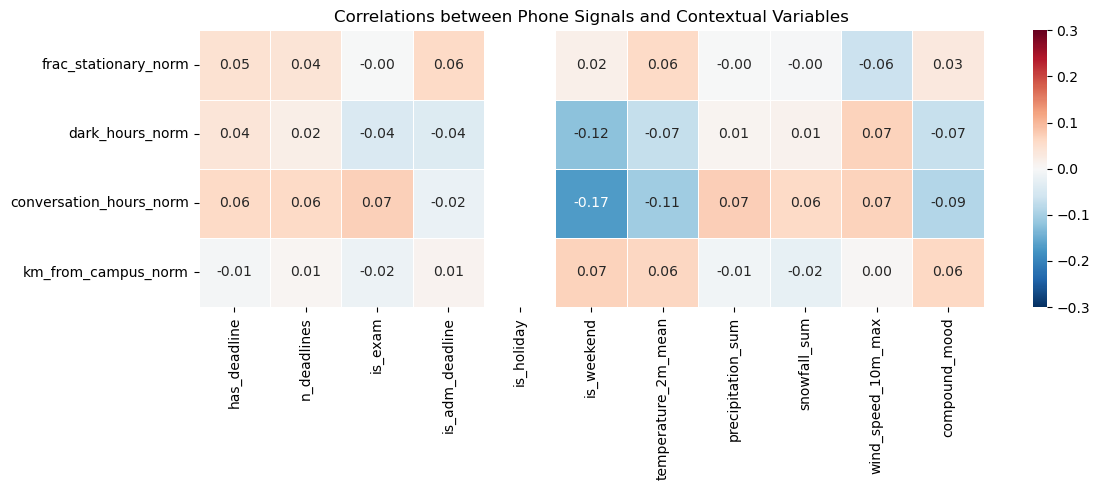

Heatmap saved to output/phone_context_correlation.png


In [110]:
# MODEL 2: Phone signals ↔ Context
# Do phone signals correlate with contextual variables?
# This shows whether context and phone behavior are related,
# motivating the need to control for context in Model 3

phone_cols = [
    "frac_stationary_norm",
    "dark_hours_norm",
    "conversation_hours_norm",
    "km_from_campus_norm"
]

context_cols = [
    "has_deadline",
    "n_deadlines",
    "is_exam",
    "is_adm_deadline",
    "is_holiday",
    "is_weekend",
    "temperature_2m_mean",
    "precipitation_sum",
    "snowfall_sum",
    "wind_speed_10m_max",
    "compound_mood"
]

df_m2 = df[phone_cols + context_cols].dropna()

# Pearson correlation between each phone signal and each contextual variable
corr_matrix = df_m2[phone_cols + context_cols].corr().loc[phone_cols, context_cols]

print("=== Model 2: Phone Signals ↔ Context (Pearson correlations) ===")
print(f"Observations used: {len(df_m2)}")
print(corr_matrix.round(3))

# Heatmap visualisation
plt.figure(figsize=(12, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.5)
plt.title("Correlations between Phone Signals and Contextual Variables")
plt.tight_layout()
plt.savefig("output/phone_context_correlation.png", dpi=150)
plt.show()
print("Heatmap saved to output/phone_context_correlation.png")

In [111]:
# MODEL 3: Phone signals + contextual confounds → Mood
# Do phone signals still associate with mood after controlling for context?
# If R² > Model 1 R², context was confounding the phone-mood relationship

model3_cols = [
    # normalised phone signals
    "frac_stationary_norm",
    "dark_hours_norm",
    "conversation_hours_norm",
    "km_from_campus_norm",
    # academic confounds
    "has_deadline",
    "n_deadlines",
    "is_exam",
    "is_adm_deadline",
    "is_holiday",
    # temporal confounds
    "is_weekend",
    # weather confounds
    "temperature_2m_mean",
    "precipitation_sum",
    "snowfall_sum",
    "wind_speed_10m_max",
    # societal confound
    "compound_mood"
]

df_m3 = df[["pam_score_mean"] + model3_cols].dropna()

X3 = df_m3[model3_cols].values
y3 = df_m3["pam_score_mean"].values

model3 = LinearRegression()
model3.fit(X3, y3)
y3_pred = model3.predict(X3)
r2_m3 = r2_score(y3, y3_pred)

print("=== Model 3: Phone Signals + Context → Mood ===")
print(f"Observations used: {len(df_m3)}")
print(f"R²: {r2_m3:.4f}")
print(f"\nCoefficients:")
for col, coef in zip(model3_cols, model3.coef_):
    print(f"  {col}: {coef:.4f}")
print(f"  Intercept: {model3.intercept_:.4f}")

print("\n=== SUMMARY ===")
print(f"Model 1 R² (phone only):        {r2_m1:.4f}")
print(f"Model 3 R² (phone + context):   {r2_m3:.4f}")
print(f"Context contribution (ΔR²):     {r2_m3 - r2_m1:.4f}")
print(f"Confounding detected:           {r2_m3 > r2_m1 + 0.005}")

=== Model 3: Phone Signals + Context → Mood ===
Observations used: 1575
R²: 0.0112

Coefficients:
  frac_stationary_norm: -0.5701
  dark_hours_norm: 0.0117
  conversation_hours_norm: -0.0185
  km_from_campus_norm: 0.0005
  has_deadline: 0.0125
  n_deadlines: 0.1055
  is_exam: 0.4394
  is_adm_deadline: 0.1727
  is_holiday: 0.0000
  is_weekend: 0.5295
  temperature_2m_mean: 0.0282
  precipitation_sum: 0.0297
  snowfall_sum: -0.1889
  wind_speed_10m_max: 0.0083
  compound_mood: -0.0075
  Intercept: 8.3207

=== SUMMARY ===
Model 1 R² (phone only):        0.0018
Model 3 R² (phone + context):   0.0112
Context contribution (ΔR²):     0.0095
Confounding detected:           True


In [112]:
# F-test: is the improvement from Model 1 to Model 3 statistically significant?
# Tests whether adding contextual confounds explains significantly more variance
# than phone signals alone, or whether the improvement could be due to chance.

n  = len(df_m3)
p1 = len(model1_cols)
p3 = len(model3_cols)

r2_m1_comparable = r2_score(y3, model1.predict(df_m3[model1_cols].values))

numerator   = (r2_m3 - r2_m1_comparable) / (p3 - p1)
denominator = (1 - r2_m3) / (n - p3 - 1)
f_stat      = numerator / denominator

p_value = 1 - stats.f.cdf(f_stat, p3 - p1, n - p3 - 1)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant at p < 0.05: {p_value < 0.05}")

F-statistic: 1.4482
p-value: 0.1451
Significant at p < 0.05: False


## 5. Results Summary
Full summary of findings across all three models.

In [113]:
# Clean summary of all three model results

print("=" * 55)
print("RESULTS SUMMARY")
print("=" * 55)
print(f"\nModel 1 — Phone signals only")
print(f"  Observations: {len(df_m1)}")
print(f"  R²: {r2_m1:.4f}")
print(f"\nModel 2 — Phone signals ↔ Context")
print(f"  Observations: {len(df_m2)}")
print(f"  See heatmap: output/phone_context_correlation.png")
print(f"\nModel 3 — Phone signals + Context → Mood")
print(f"  Observations: {len(df_m3)}")
print(f"  R²: {r2_m3:.4f}")
print(f"  ΔR² (Model 3 - Model 1): {r2_m3 - r2_m1:.4f}")
print(f"\nF-test (Model 1 vs Model 3)")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Significant at p < 0.05: {p_value < 0.05}")
print(f"\nConclusion:")
print(f"  Adding contextual confounds improved R² by "
      f"{r2_m3/r2_m1:.0f}x over phone signals alone.")
print(f"  The improvement is {'statistically significant' if p_value < 0.05 else 'not statistically significant'} "
      f"(p = {p_value:.3f}).")
print(f"  This is a proof-of-concept pipeline — the directional")
print(f"  finding supports context-aware digital phenotyping.")

RESULTS SUMMARY

Model 1 — Phone signals only
  Observations: 1758
  R²: 0.0018

Model 2 — Phone signals ↔ Context
  Observations: 1575
  See heatmap: output/phone_context_correlation.png

Model 3 — Phone signals + Context → Mood
  Observations: 1575
  R²: 0.0112
  ΔR² (Model 3 - Model 1): 0.0095

F-test (Model 1 vs Model 3)
  F-statistic: 1.4482
  p-value: 0.1451
  Significant at p < 0.05: False

Conclusion:
  Adding contextual confounds improved R² by 6x over phone signals alone.
  The improvement is not statistically significant (p = 0.145).
  This is a proof-of-concept pipeline — the directional
  finding supports context-aware digital phenotyping.


# Use of AI 

ChatGPT-5 was used for the debugging and refactoring the code.  